<a href="https://colab.research.google.com/github/241541601038-glitch/JALIZ/blob/main/EX10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving pan.jpg to pan.jpg


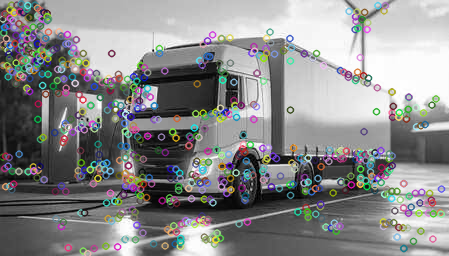

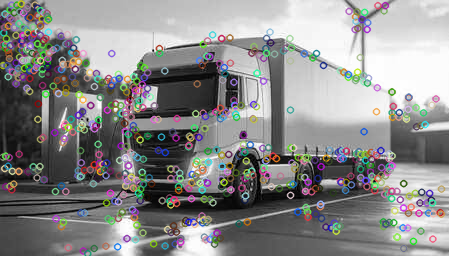

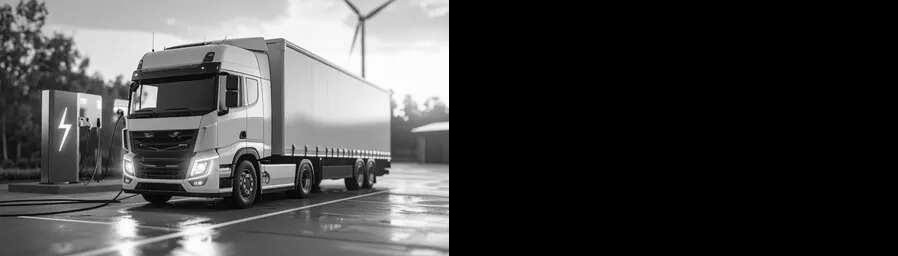

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

def simple_stitch(img1, img2):
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        print("Descriptors not found.")
        return None

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)

    if len(matches) < 4:
        print("Not enough matches found.")
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
    H, status = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

    if H is None:
        print("Homography could not be computed.")
        return None

    height, width = img1.shape
    panorama = cv2.warpPerspective(img2, H, (width * 2, height))
    panorama[0:height, 0:width] = img1
    return panorama

# Main execution block
img1 = cv2.imread('pan.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('pan.jpg', cv2.IMREAD_GRAYSCALE) # Assuming you have another image or want to use the same one for demonstration

if img1 is None or img2 is None:
    print("One or both images could not be loaded. Please ensure 'two.jpg.jpg' (or your other image) is uploaded.")
else:
    sift_detector = cv2.SIFT_create()
    kp_img1 = cv2.drawKeypoints(img1, sift_detector.detect(img1), None)
    kp_img2 = cv2.drawKeypoints(img2, sift_detector.detect(img2), None)
    cv2_imshow(kp_img1)
    cv2_imshow(kp_img2)

    panorama = simple_stitch(img1, img2)
    if panorama is not None:
        cv2_imshow(panorama)
    else:
        print("Panorama could not be created.")